In [1]:
import json
import pandas as pd
from cbb.scrape import kenpom
from cbb.lib import paths, teams

pd.set_option('display.colheader_justify', 'center')
S16 =  ["Duke", "Connecticut", "Arizona", "Michigan", "Tennessee", "Illinois"]
M1 = S16[0:2]
M2 = S16[2:4]
M3 = S16[4:6]
M4 = []
M5 = []
M6 = []
M7 = []
M8 = []
TOT_TEAMS = 364

s16_file = paths.M_KEN_DIR / "2026-03-26.json"
with open(s16_file, "r", encoding="utf-8") as f:
    data = json.load(f)

kenpom_data = pd.DataFrame(data["rows"], columns=data["headers"])
tourney_teams = kenpom_data[kenpom_data["Seed"] > 0].sort_values(by="Seed")
tourney_teams = tourney_teams.rename(columns={"TeamName" : "Team"})
tourney_teams["S16"] = tourney_teams["Team"].isin(S16)
def highlight_specific_matchup(row):
    if row['Team'] in M1:
        return ['background-color: paleturquoise'] * len(row)
    elif row['Team'] in M2:
        return ['background-color: salmon'] * len(row)
    elif row['Team'] in M3:
        return ['background-color: goldenrod'] * len(row)
    elif row['Team'] in M4:
        return ['background-color: lightgreen'] * len(row)
    elif row['Team'] in M5:
        return ['background-color: lightpink'] * len(row)
    elif row['Team'] in M6:
        return ['background-color: plum'] * len(row)
    elif row['Team'] in M7:
        return ['background-color: yellow'] * len(row)
    elif row['Team'] in M8:
        return ['background-color: peachpuff'] * len(row)
    else:
        return [''] * len(row)

In [2]:
def logos(row):
    if row['S16'] == 1:
        return teams.getTeamLogoShort(row["Team"])
    else:
        return ''
tourney_teams["logo"] = tourney_teams.apply(lambda x: logos(x), axis =1)

##  Men's E8  & F4 Stats  
# Free Throw Rankings  

In [3]:
# Free Throw Data 
tourney_teams["FTPercentile"] = 100*((TOT_TEAMS - tourney_teams["RankFTPct"]) / TOT_TEAMS)
s16 = tourney_teams[tourney_teams["S16"] == True]
s16 = s16.rename(columns={"FTPct":"FT %", "RankFTPct" : "Natl. Rank", "FTPercentile" : "Percentile"})
ftr = s16[["Team","Seed", "FT %", "Natl. Rank", "Percentile"]].sort_values(by="FT %", ascending=False)
ftr['Percentile'] = ftr["Percentile"].round(0)
ftr = ftr.style \
    .hide(axis='index') \
    .apply(highlight_specific_matchup, axis=1) \
    .set_properties(**{'text-align': 'center'}).set_table_styles([
        dict(selector='th', props=[('text-align', 'center')]) 
    ]) \
    .format({'FT %': '{:.2%}'}) \
    .format({"Percentile" : "{:.0f}th".format})

ftr

Team,Seed,FT %,Natl. Rank,Percentile
Illinois,3,78.437000,13,96th
Michigan,1,74.692900,96,74th
Duke,1,73.173800,162,55th
Arizona,1,72.992700,170,53th
Connecticut,2,72.213500,200,45th
Tennessee,6,69.607800,281,23th


## Elite 8 & F4 Charts

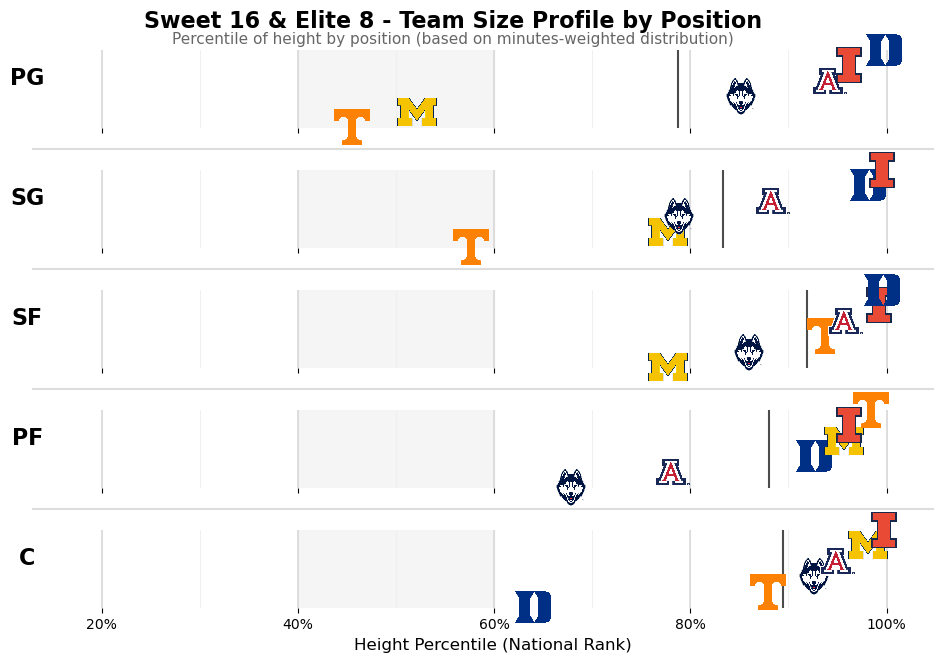

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# -----------------------------
# Setup
# -----------------------------
df = tourney_teams[[
    "Team", "Seed", "S16", "logo",
    "Hgt1Rank", "Hgt2Rank", "Hgt3Rank", "Hgt4Rank", "Hgt5Rank"
]]

df = df.rename(columns={
    "Hgt1Rank": "PG",
    "Hgt2Rank": "SG",
    "Hgt3Rank": "SF",
    "Hgt4Rank": "PF",
    "Hgt5Rank": "C"
})

positions = ["PG", "SG", "SF", "PF", "C"]

# -----------------------------
# Convert ranks → percentiles FIRST
# -----------------------------
for pos in positions:
    df[pos] = 1 - (df[pos] - 1) / (TOT_TEAMS - 1)

df_plot = df[df["S16"] == 1].reset_index(drop=True)

# -----------------------------
# Figure
# -----------------------------
fig_height = 0.8 * len(df_plot) + 2
fig, axes = plt.subplots(5, 1, figsize=(10, fig_height), sharex=True)

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.90,
    bottom=0.08,
    hspace=0.55
)

# -----------------------------
# X range
# -----------------------------
x_min = df_plot[positions].min().min()
x_max = df_plot[positions].max().max()

x_min = min(x_min, 0.2)
x_max = max(x_max, 0.8)

pad = 0.05
x_min = max(0, x_min - pad)
x_max = min(1.15, x_max + pad)

# -----------------------------
# Percentile ticks
# -----------------------------
major_ticks = np.arange(0, 1.01, 0.2)   # 0,20,...100
minor_ticks = np.arange(0, 1.01, 0.1)   # 10% steps

major_ticks = [t for t in major_ticks if x_min <= t <= x_max]
minor_ticks = [t for t in minor_ticks if x_min <= t <= x_max]

# -----------------------------
# Plot
# -----------------------------
for i, pos in enumerate(positions):
    ax = axes[i]

    temp = df_plot.sort_values(pos).reset_index(drop=True)
    y_vals = np.arange(len(temp))

    # 🔥 Background band (average)
    ax.axvspan(0.4, 0.6, color="#f5f5f5", zorder=0)

    # 🔥 Minor grid (light)
    for t in minor_ticks:
        ax.axvline(t, color="#f0f0f0", linewidth=0.8, zorder=0)

    # 🔥 Major grid (stronger)
    for t in major_ticks:
        ax.axvline(t, color="#d9d9d9", linewidth=1.2, zorder=0)

    # 🔥 Logos
    for j, row in temp.iterrows():
        x = row[pos]
        y = j

        path = paths.ASSET_IMG_DIR / row["logo"]
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.055)

        ab = AnnotationBbox(im, (x, y), frameon=False)
        ax.add_artist(ab)

    # 🔥 Average line
    avg = temp[pos].mean()
    ax.axvline(avg, color="black", linewidth=1.5, alpha=0.7)

    # Remove labels but keep spacing
    ax.set_yticks(y_vals)
    ax.set_yticklabels([])


    ax.set_xlim(x_min, x_max)

    # 🔥 Show ticks on EVERY subplot
    ax.set_xticks(major_ticks)
    ax.set_xticklabels([f"{int(t*100)}%" for t in major_ticks], fontsize=10)
    
    ax.set_ylabel(pos, rotation=0, fontsize=16, fontweight="bold", labelpad=15)

for i in range(len(axes) - 1):
    # bottom of current axis
    y_top_next = axes[i+1].get_position().y1
    y_bottom_current = axes[i].get_position().y0

    # midpoint of the gap between plots
    y = (y_bottom_current + y_top_next) / 2

    fig.add_artist(plt.Line2D(
        [0.08, 0.98],   # match your left/right margins
        [y, y],
        transform=fig.transFigure,
        color="#dddddd",
        linewidth=1.5
    ))

# -----------------------------
# Bottom label
# -----------------------------
axes[-1].set_xlabel("Height Percentile (National Rank)", fontsize=12)

# -----------------------------
# Clean styling
# -----------------------------
for ax in axes:
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.tick_params(axis='y', length=0)

# -----------------------------
# Titles
# -----------------------------
fig.suptitle(
    "Sweet 16 & Elite 8 - Team Size Profile by Position",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5, 0.91,
    "Percentile of height by position (based on minutes-weighted distribution)",
    ha="center",
    fontsize=11,
    color="#666"
)

plt.show()


# Adj. Offensive Efficiency (y) vs Adj. Defensive Efficiency (x)
All 2026 Tournament Teams  
Lower = Better Defense  
Right = Better Offense  

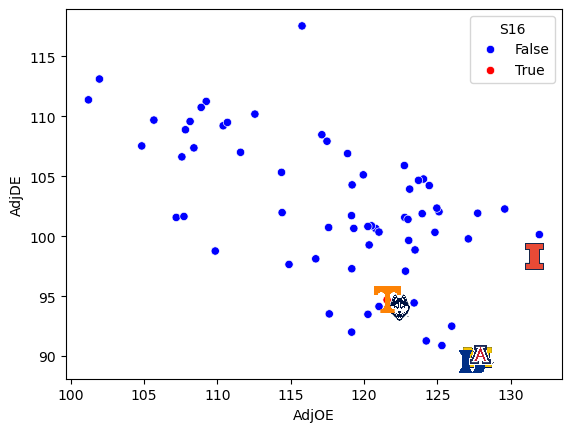

In [5]:
# Efficiency
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

eff = tourney_teams[["Team","Seed", "AdjOE", "AdjDE", 'S16', 'logo']]
fig, ax = plt.subplots()
g = sns.scatterplot(data=eff, x='AdjOE', y='AdjDE', hue='S16', palette={0: 'blue', 1: 'red'})
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.04) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjOE'], row['AdjDE']), frameon=False)
        ax.add_artist(ab)
plt.show()



# Adj. Offensive Efficiency (y) vs Adj. Defensive Efficiency (x)
Only teams left
Lower = Better Defense  
Right = Better Offense



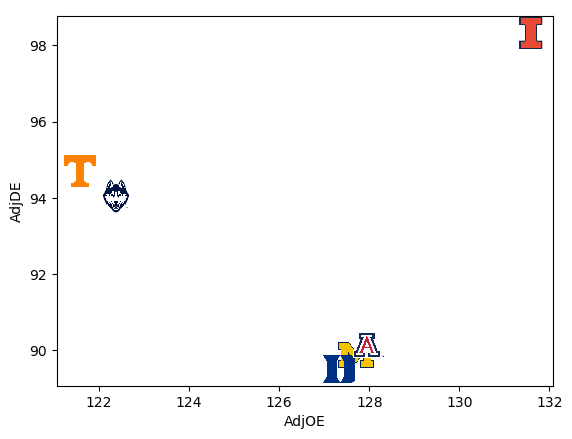

In [6]:
fig, ax = plt.subplots()
g = sns.scatterplot(
    data=eff[eff['S16'] == 1],
    x='AdjOE',
    y='AdjDE',
    alpha=0,        # 🔥 hides dots
    legend=False
)
for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.05) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['AdjOE'], row['AdjDE']), frameon=False)
        ax.add_artist(ab)
plt.show()


## 3 Pt %  - Scored (x) vs Allowed (y)
Higher = Give up more 3s  
Right  = Make more 3s  


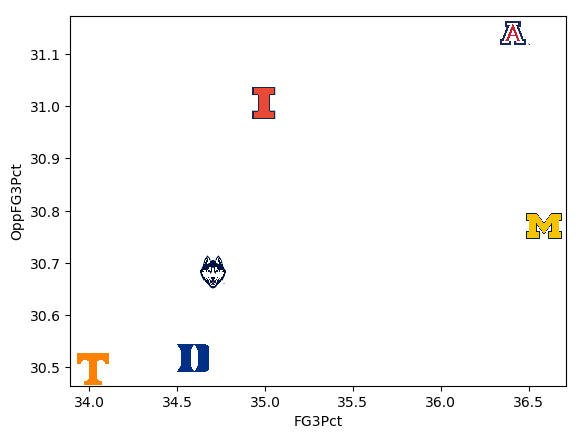

In [7]:
eff = tourney_teams[["Team","Seed", "FG3Pct", "OppFG3Pct", 'S16', 'logo']]
fig, ax = plt.subplots()
g = sns.scatterplot(
    data=eff[eff['S16'] == 1],
    x='FG3Pct',
    y='OppFG3Pct',
    alpha=0,        # 🔥 hides dots
    legend=False
)

for i, row in eff.iterrows():
    if row['S16'] == 1:
        # Load image
        path = paths.ASSET_IMG_DIR / row['logo']
        img = plt.imread(path)
        im = OffsetImage(img, zoom=0.05) # Adjust zoom as necessary
        
        # Create AnnotationBbox
        ab = AnnotationBbox(im, (row['FG3Pct'], row['OppFG3Pct']), frameon=False)
        ax.add_artist(ab)
plt.show()
